# Разведочный анализ данных: Task04 Hippocampus (Medical Segmentation Decathlon)

Работа выполнена в рамках задачи сегментации гиппокампа на структурной магнитно-резонансной
томографии. Разведочный анализ устанавливает количественные характеристики набора данных,
формирующие проектные решения по препроцессингу, выбору функции потерь и архитектуре
сегментационной модели. Содержание следует структуре медицинского исследования: введению с
клиническим контекстом, описанию материалов и методов, результатам анализа и обсуждению с
проектными решениями.


## Введение

### Клинический и анатомический контекст

Гиппокамп — структура медиальной части височной доли головного мозга, входящая в
лимбическую систему. Анатомически он представляет собой удлинённое серое вещество,
изогнутое вдоль продольной оси височной доли, длиной приблизительно 4–4.5 см у взрослого
человека. Принято выделять три отдела: головку (head), тело (body) и хвост (tail).
Гиппокамп присутствует с обеих сторон мозга — левый и правый — и в норме характеризуется
билатеральной симметрией объёма.

Функционально гиппокамп критически вовлечён в формирование декларативной памяти,
консолидацию следов из кратковременной в долговременную память и пространственную навигацию.
Двусторонние повреждения гиппокампа приводят к антероградной амнезии, что было установлено
на классическом клиническом наблюдении пациента H.M. (Scoville and Milner, 1957).

### Клиническая значимость количественной оценки

Объём гиппокампа служит установленным нейровизуализационным биомаркером ряда заболеваний:

* **Болезнь Альцгеймера.** Атрофия гиппокампа предшествует клинической манифестации
  деменции и обладает высокой диагностической ценностью на стадии лёгкого когнитивного
  нарушения; снижение объёма наблюдается со скоростью 3–5 % в год у пациентов с болезнью
  Альцгеймера против ~0.5 % при физиологическом старении (Jack et al., 2010, NIA-AA criteria).
* **Височная эпилепсия.** Мезиальный темпоральный склероз — наиболее частая патоморфологическая
  основа фармакорезистентной височной эпилепсии — проявляется уменьшением объёма и изменением
  сигнала гиппокампа на T1- и T2-взвешенных изображениях.
* **Прочие состояния:** посттравматическое стрессовое расстройство, депрессия, шизофрения
  ассоциированы с уменьшением объёма гиппокампа на групповом уровне.

Норма объёма гиппокампа на одной стороне мозга у здорового взрослого по данным
автоматизированной волюметрии (FreeSurfer, FSL FIRST) составляет ориентировочно
3 000–4 500 мм³ с существенной зависимостью от пола, возраста и общего объёма мозга.
Точная сегментация гиппокампа и измерение его объёма имеют, таким образом, прямую
клиническую значимость.

### Раздельная сегментация передней и задней подобластей

В данных Medical Segmentation Decathlon гиппокамп размечен с раздельным выделением двух
подобластей:

* **Anterior (метка 1)** — передняя часть, соответствующая головке гиппокампа.
* **Posterior (метка 2)** — задняя часть, объединяющая тело и хвост.

Раздельная сегментация мотивирована неравномерным вовлечением подобластей в патологические
процессы: при болезни Альцгеймера атрофия преимущественно затрагивает CA1-область,
анатомически расположенную в головке; при височной эпилепсии типичны изменения в теле
гиппокампа. Раздельное измерение объёмов повышает чувствительность к ранним и
локализованным изменениям. Это определяет многоклассовую постановку задачи (три класса с
учётом фона).

### Выбор модальности

Структурная T1-взвешенная магнитно-резонансная томография является стандартом
нейровизуализационной оценки серого вещества и позволяет различить гиппокамп от
окружающих структур (височный рог бокового желудочка, амигдала, парагиппокампальная извилина)
благодаря высокому контрасту серое/белое вещество. Компьютерная томография применима к
головному мозгу преимущественно в острых состояниях и не пригодна для морфометрии серого
вещества вследствие низкого мягкотканного контраста.

### Цель разведочного анализа

Целью настоящего разведочного анализа является количественная характеризация набора данных
в объёме, достаточном для обоснованного выбора параметров препроцессинга, архитектуры
сегментационной модели и функции потерь. Анализ должен дать ответы на следующие вопросы:

1. Какова геометрия томограмм и физическое разрешение, требуется ли ресэмплинг?
2. Каково распределение интенсивностей, требуется ли нормализация и какого типа?
3. Какова степень дисбаланса классов, какая функция потерь применима?
4. Каковы размер и пространственное расположение целевых структур, оправдано ли кадрирование?
5. Каков локальный контраст границы структуры, что определяет требования к модели?
6. Какова топологическая структура разметки и каков состав целевой структуры в томограмме?


## Материалы и методы

### Источник данных

Набор данных — задача Task04 (Hippocampus) бенчмарка Medical Segmentation Decathlon
(MSD): открытый эталонный сборник из десяти задач трёхмерной медицинской сегментации,
объединяющий данные различных модальностей, органов и патологий. Описание методологии и
данных приведено в работе Antonelli et al., *The Medical Segmentation Decathlon*, Nature
Communications 13, 4128 (2022), [doi:10.1038/s41467-022-30695-9](https://doi.org/10.1038/s41467-022-30695-9).
Данные опубликованы под лицензией Creative Commons Attribution-ShareAlike 4.0.

### Этические аспекты

Все исследования набора деидентифицированы: персональные идентификаторы и
дополнительные клинические сведения недоступны. Дополнительные демографические данные
(возраст, пол, диагноз) в публичной версии отсутствуют, что ограничивает возможность
групповых сопоставлений и стратификации.

### Когорта и характер исследования

Набор содержит **390 исследований**: 260 размеченных (обучающая выборка) и 130 без разметки
(тестовая выборка). Каждое исследование представляет собой структурную трёхмерную
T1-взвешенную магнитно-резонансную томографию, предварительно обрезанную вокруг одного
гиппокампа — выделенной области вокруг одной стороны мозга. Эта характеристика данных
подтверждается далее в результатах анализа и существенна для интерпретации морфометрических
измерений и последующей оценки модели.

### Формат данных

Данные хранятся в формате NIfTI (`.nii.gz`) — стандарте нейровизуализации, размещающем в
одном файле трёхмерный воксельный массив и пространственные метаданные: матрицу аффинного
преобразования, физический размер вокселя и кодирование осей. Поддерживается стандартом
DICOM-NIfTI согласно конвенциям Brain Imaging Data Structure (BIDS).

### Характер разметки

Экспертная разметка выполнена радиологами в рамках MSD и представлена воксельной маской с
тремя метками: фон (0), Anterior (1), Posterior (2). Разметка является многоклассовой и
плотной (каждый воксель отнесён к одному классу).

### Конвенции пространственной ориентации

В анализе и обучении объёмы приводятся к стандартной ориентации **RAS** (Right–Anterior–
Superior): оси координат направлены в стандартные анатомические стороны. Унификация
ориентации устраняет расхождения в кодировании осей между исследованиями и обеспечивает
анатомически корректную интерпретацию сечений.


## Подготовка среды исполнения

Анализ использует фреймворк MONAI (Medical Open Network for AI), специализированный для
медицинской визуализации; библиотеку `nibabel` для доступа к метаданным NIfTI; `scipy.ndimage`
для анализа связных компонент и морфологических операций; `matplotlib` и `plotly` для
визуализаций. Фиксируется единый случайный seed и согласованный стиль построения графиков для
воспроизводимости результатов.


In [1]:
!pip install -q "monai[nibabel,tqdm]==1.5.1" "nibabel==5.2.1" matplotlib scipy plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.7 MB/s eta 0:00:00


In [2]:
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import nibabel as nib
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import ndimage

import monai
from monai.transforms import LoadImage

# ───────────────────────── Воспроизводимость ─────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ───────────────────────── Стиль визуализаций ─────────────────────────
# Единый стиль для всех графиков. Согласованные шрифты, тонкие сетки,
# скрытые верхние и правые рамки, повышенный DPI для печатного качества.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titlepad": 8,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 12.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

print("Окружение:")
print(f"  MONAI : {monai.__version__}")
print(f"  NumPy : {np.__version__}")
print(f"  Seed  : {SEED}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Окружение:
  MONAI : 1.5.1
  NumPy : 2.0.2
  Seed  : 42


### Подключение хранилища и конфигурации

Репозиторий проекта и данные размещаются на Google Drive в раздельных каталогах. После
монтирования диска конфигурация импортируется из модуля `src/config.py` — единого источника
путей и параметров. Расположение данных не задаётся в ноутбуке явно, что исключает
дублирование путей между ноутбуками.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import sys
PROJECT_ROOT = Path("/content/drive/MyDrive/hippocampus-segmentation")
sys.path.append(str(PROJECT_ROOT))

from src.config import cfg

DATA_DIR = cfg.data_dir
print(f"Задача          : {cfg.task_name}")
print(f"Каталог данных  : {DATA_DIR}")
print(f"Число классов   : {cfg.num_classes}")
print(f"Метки           : {cfg.labels}")


Задача          : Task04_Hippocampus
Каталог данных  : /content/drive/MyDrive/msd_tasks/Task04_Hippocampus
Число классов   : 3
Метки           : {0: 'background', 1: 'Anterior', 2: 'Posterior'}


In [5]:
# Контроль целостности структуры набора данных
for sub in ["imagesTr", "labelsTr", "imagesTs", cfg.dataset_json]:
    assert (DATA_DIR / sub).exists(), f"Отсутствует элемент структуры: {sub}"
print("Структура каталога соответствует спецификации MSD.")


Структура каталога соответствует спецификации MSD.


## Результаты разведочного анализа

### 1. Метаданные `dataset.json`

Файл `dataset.json` содержит описание модальностей, словарь меток и явный перечень пар
«изображение–разметка». Этот перечень служит источником соответствия изображений и масок,
что предпочтительнее независимого сканирования каталогов, поскольку устраняет риск
несогласованности файлов между подкаталогами `imagesTr` и `labelsTr`.


In [6]:
with open(DATA_DIR / cfg.dataset_json, encoding="utf-8") as f:
    meta = json.load(f)

print(f"Название задачи         : {meta.get('name')}")
print(f"Модальность             : {meta.get('modality')}")
print(f"Метки                   : {meta.get('labels')}")
print(f"Объём обучающей выборки : {meta.get('numTraining')}")
print(f"Объём тестовой выборки  : {meta.get('numTest')}")
print(f"\nПример записи обучающей выборки:")
print(f"  {meta['training'][0]}")


Название задачи         : Hippocampus
Модальность             : {'0': 'MRI'}
Метки                   : {'0': 'background', '1': 'Anterior', '2': 'Posterior'}
Объём обучающей выборки : 260
Объём тестовой выборки  : 130

Пример записи обучающей выборки:
  {'image': './imagesTr/hippocampus_367.nii.gz', 'label': './labelsTr/hippocampus_367.nii.gz'}


**Выводы.** Конфигурационный файл подтверждает многоклассовую постановку задачи: словарь
меток содержит фон (0) и две целевые подобласти — Anterior (1) и Posterior (2). Модальность
определена как магнитно-резонансная томография с единственным каналом. Обучающая выборка
насчитывает 260 размеченных томограмм, тестовая — 130 томограмм без разметки. Записи
обучающей выборки задают пары «изображение–разметка» относительными путями, что используется
далее для гарантированного сопоставления. На основании полученных значений финальная
активация модели и функция потерь проектируются под три класса с учётом фона.


### 2. Геометрические характеристики томограмм

Анализируются пространственные размеры томограмм (число вокселей по осям) и физический
размер вокселя (`voxel spacing`, мм). Эти величины определяют две проектные необходимости:

1. **Приведение к единому размеру.** Сегментационные архитектуры с многократным понижением
   разрешения требуют входа фиксированной формы, кратной соответствующей степени двойки.
   Разброс размеров томограмм требует операции приведения (дополнение либо обрезка).
2. **Необходимость ресэмплинга.** Различие физического разрешения между исследованиями
   потребовало бы ресэмплинга к единой решётке; однородное разрешение, напротив, делает
   ресэмплинг излишним и упрощает последующую оценку объёма в физических единицах.


In [7]:
img_paths = sorted((DATA_DIR / "imagesTr").glob("*.nii.gz"))
lbl_paths = sorted((DATA_DIR / "labelsTr").glob("*.nii.gz"))
assert len(img_paths) == len(lbl_paths), "Несоответствие числа изображений и масок"

shapes, spacings = [], []
for p in img_paths:
    h = nib.load(str(p)).header
    shapes.append(tuple(int(d) for d in h.get_data_shape()))
    spacings.append(tuple(round(float(z), 3) for z in h.get_zooms()))

shapes_arr = np.array(shapes)
print(f"Число томограмм           : {len(shapes)}")
print(f"Размер (воксели), min     : {tuple(shapes_arr.min(0))}")
print(f"Размер (воксели), max     : {tuple(shapes_arr.max(0))}")
print(f"Размер (воксели), медиана : {tuple(int(v) for v in np.median(shapes_arr, 0))}")
print(f"Размер (воксели), среднее : {tuple(round(float(v), 1) for v in shapes_arr.mean(0))}")
print(f"Уникальные voxel spacing  : {Counter(spacings).most_common()}")


Число томограмм           : 260
Размер (воксели), min     : (np.int64(31), np.int64(40), np.int64(24))
Размер (воксели), max     : (np.int64(43), np.int64(59), np.int64(47))
Размер (воксели), медиана : (35, 50, 36)
Размер (воксели), среднее : (35.4, 50.0, 35.7)
Уникальные voxel spacing  : [((1.0, 1.0, 1.0), 260)]


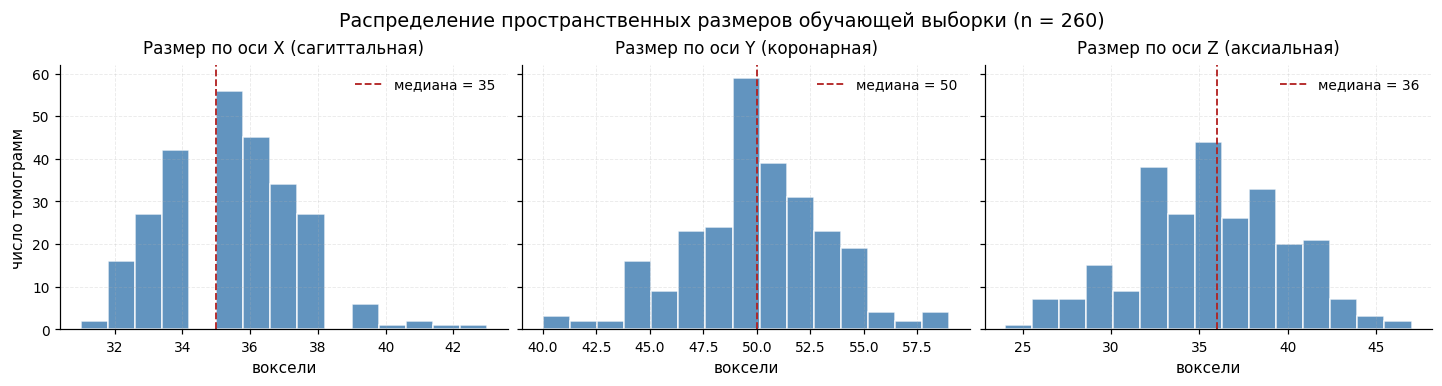

In [8]:
# Распределения размеров по трём осям + сводная статистика на одном рисунке.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True,
                         constrained_layout=True)
axis_names = ["X (сагиттальная)", "Y (коронарная)", "Z (аксиальная)"]
for i, name in enumerate(axis_names):
    data = shapes_arr[:, i]
    axes[i].hist(data, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(np.median(data), color="firebrick", linestyle="--", linewidth=1.2,
                    label=f"медиана = {int(np.median(data))}")
    axes[i].set_title(f"Размер по оси {name}")
    axes[i].set_xlabel("воксели")
    axes[i].legend(loc="upper right")
axes[0].set_ylabel("число томограмм")
fig.suptitle("Распределение пространственных размеров обучающей выборки (n = 260)")
plt.show()


**Выводы.** Томограммы имеют малые и переменные пространственные размеры: от 31×40×24 до
43×59×47 вокселя при медианном размере 35×50×36. Малость размеров означает, что каждая
томограмма целиком размещается в памяти графического процессора, что делает возможным
обучение полностью трёхмерной модели без разбиения на патчи — подхода, как правило
вынужденного для полноразмерных томограмм. Переменность размеров требует приведения к
единой форме; применяется приведение к фиксированному размеру **48×64×48**, превосходящему
максимальный наблюдаемый размер по каждой оси и кратному степени двойки, что согласуется
с многократным понижением разрешения в архитектуре кодировщика.

Физический размер вокселя постоянен и изотропен во всей выборке и составляет **1×1×1 мм**
(единственное наблюдаемое значение для всех 260 томограмм). Однородность разрешения
устраняет необходимость ресэмплинга — медицински важный факт, обеспечивающий прямое
сопоставление морфометрических измерений между субъектами. Изотропность вокселя
дополнительно означает, что оценка объёма органа сводится к подсчёту вокселей переднего
плана, поскольку объём одного вокселя равен 1 мм³.


### 3. Распределение интенсивностей

Интенсивности магнитно-резонансной томографии, в отличие от единиц Хаунсфилда компьютерной
томографии, не имеют единой физической шкалы и существенно зависят от параметров сканера,
последовательности и протокола исследования. Анализ масштаба интенсивностей определяет
стратегию нормализации, без которой обучение дестабилизируется различием масштабов входных
данных между исследованиями. Анализ распределения интенсивностей внутри отдельной томограммы
дополнительно характеризует структуру данных (преимущественно положительные значения,
сильно скошенное распределение, ненулевая мода).


In [9]:
loader = LoadImage(image_only=True, ensure_channel_first=True)

# Расширенная выборка для статистики масштаба интенсивностей
SAMPLE_N = 40
sample_paths = img_paths[:SAMPLE_N]

vmins, vmaxs, vmeans, vstds = [], [], [], []
for p in sample_paths:
    vol = loader(str(p)).numpy()
    nonzero = vol[vol > 0]
    vmins.append(float(vol.min()))
    vmaxs.append(float(vol.max()))
    vmeans.append(float(nonzero.mean()))
    vstds.append(float(nonzero.std()))

print(f"Статистики по выборке из {SAMPLE_N} томограмм:")
print(f"  Глобальный минимум        : {min(vmins):.1f}")
print(f"  Глобальный максимум       : {max(vmaxs):.1f}")
print(f"  Std максимумов            : {np.std(vmaxs):.1f}")
print(f"  Среднее (по ненулевым), min..max : "
      f"{min(vmeans):.1f} .. {max(vmeans):.1f}")


Статистики по выборке из 40 томограмм:
  Глобальный минимум        : 0.0
  Глобальный максимум       : 358214.7
  Std максимумов            : 55561.6
  Среднее (по ненулевым), min..max : 63.5 .. 179067.0


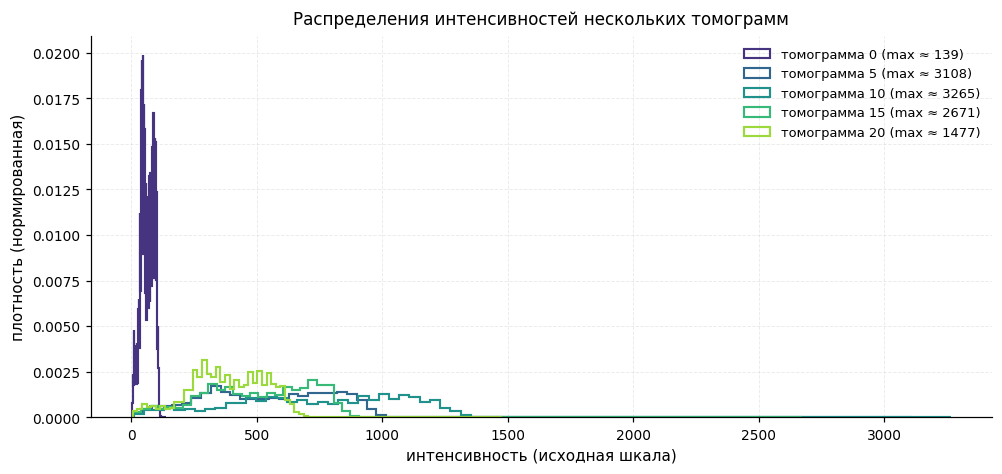

In [10]:
# Распределения интенсивностей нескольких отдельных томограмм. На едином графике
# отчётливо видно как общую правоскошенную форму, типичную для T1-MRI, так и расхождение
# масштабов между исследованиями: пиковые значения отличаются на порядки.

fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)

example_idx = [0, 5, 10, 15, 20]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(example_idx)))
for c, idx in zip(colors, example_idx):
    vol = loader(str(sample_paths[idx])).numpy().ravel()
    vol = vol[vol > 0]
    ax.hist(vol, bins=80, histtype="step", color=c, linewidth=1.4,
            density=True, label=f"томограмма {idx} (max ≈ {vol.max():.0f})")
ax.set_xlabel("интенсивность (исходная шкала)")
ax.set_ylabel("плотность (нормированная)")
ax.set_title("Распределения интенсивностей нескольких томограмм")
ax.legend(loc="upper right", fontsize=8.5)
plt.show()


**Выводы.** Анализ подтверждает отсутствие единой физической шкалы интенсивностей: средние
интенсивности по ненулевым вокселям различаются между исследованиями на четыре порядка,
максимумы — на порядки соответственно. Использование исходных интенсивностей напрямую
эквивалентно подаче в модель данных в несопоставимых масштабах между субъектами и
дестабилизирует обучение.

Распределение интенсивностей внутри отдельной томограммы — преимущественно положительное,
сильно правоскошенное, с выраженной модой в области интенсивностей серого вещества и
длинным правым хвостом, соответствующим белому веществу и спинномозговой жидкости. Такая
форма характерна для структурной T1-MRI после удаления фона воздуха.

**Применяемое следствие.** К каждой томограмме применяется поэлементная z-нормализация
(вычитание среднего и деление на стандартное отклонение по ненулевым вокселям данной
томограммы). Нормализация по отдельной томограмме приводит интенсивности всех исследований
к сопоставимому масштабу, не опираясь на глобальную статистику набора, что важно для
обобщения на новые данные. Ограничение статистики ненулевыми вокселями исключает влияние
фонового воздуха, отнесённого алгоритмом B0-предобработки к нулевой интенсивности.


### 4. Баланс классов

Доля вокселей переднего плана относительно фона определяет степень дисбаланса классов —
фундаментальную особенность медицинской сегментации, где целевые структуры занимают малую
долю объёма исследования. Степень дисбаланса обуславливает выбор функции потерь: при
выраженном дисбалансе попиксельная кросс-энтропия склонна к вырожденному решению, при котором
повсеместное предсказание фона обеспечивает высокую попиксельную точность при отсутствии
содержательной сегментации.


In [11]:
counts = {k: 0 for k in cfg.labels}
contains_both = 0

for p in lbl_paths:
    m = loader(str(p)).numpy().astype(np.int16)
    u, c = np.unique(m, return_counts=True)
    present = dict(zip(u.tolist(), c.tolist()))
    for k in counts:
        counts[k] += present.get(k, 0)
    if all(fg in present for fg in cfg.foreground_labels):
        contains_both += 1

total = sum(counts.values())
print("Распределение вокселей по классам (агрегировано по всему обучающему набору):\n")
for k, name in cfg.labels.items():
    pct = 100 * counts[k] / total
    print(f"  {name:12s} ({k}) : {counts[k]:>13,} вокселей  ({pct:5.2f} %)")

fg = sum(counts[k] for k in cfg.foreground_labels)
print(f"\n  Передний план (всего)  : {100 * fg / total:.2f} %")
print(f"  Соотношение фон : цель ≈ {counts[0] // fg} : 1")
print(f"  Масок со всеми классами переднего плана: {contains_both} из {len(lbl_paths)}")


Распределение вокселей по классам (агрегировано по всему обучающему набору):

  background   (0) :    15,469,502 вокселей  (94.75 %)
  Anterior     (1) :       445,938 вокселей  ( 2.73 %)
  Posterior    (2) :       410,816 вокселей  ( 2.52 %)

  Передний план (всего)  : 5.25 %
  Соотношение фон : цель ≈ 18 : 1
  Масок со всеми классами переднего плана: 260 из 260


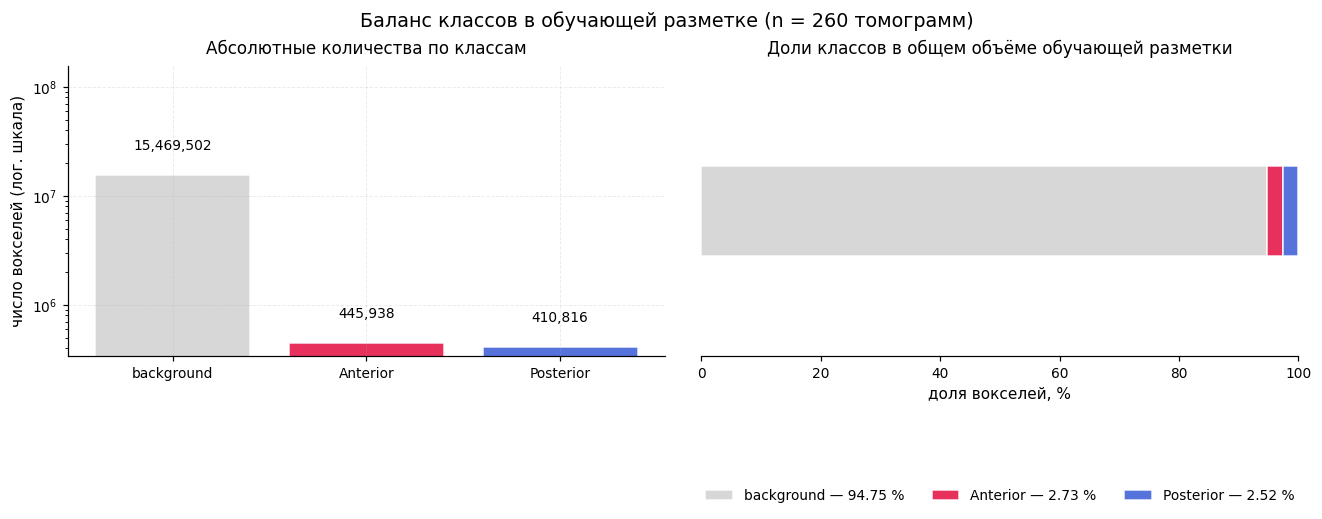

In [12]:
from src.visualization import CLASS_COLORS, CLASS_NAMES

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

# Левая панель: абсолютные количества в логарифмической шкале с подписями над столбцами
names_full = [cfg.labels[k] for k in cfg.labels]
vals = [counts[k] for k in cfg.labels]
colors_bar = ["lightgray"] + [CLASS_COLORS[k] for k in cfg.labels if k != 0]
bars = ax[0].bar(names_full, vals, color=colors_bar, edgecolor="white", alpha=0.9)
ax[0].set_yscale("log")
ax[0].set_ylabel("число вокселей (лог. шкала)")
ax[0].set_title("Абсолютные количества по классам")
# Подписи над столбцами с запасом по вертикали
ax[0].set_ylim(top=max(vals) * 10)
for bar, v in zip(bars, vals):
    ax[0].text(bar.get_x() + bar.get_width() / 2, v * 1.6,
               f"{v:,}", ha="center", va="bottom", fontsize=9)

# Правая панель: горизонтальная диаграмма-разбиение долей с внешней легендой,
# показывающей точные проценты для каждого класса.
pct = [100 * v / total for v in vals]
left = 0
for name, p, c in zip(names_full, pct, colors_bar):
    ax[1].barh([0], [p], left=left, color=c, edgecolor="white", height=0.5, alpha=0.9,
               label=f"{name} — {p:.2f} %")
    left += p
ax[1].set_xlim(0, 100)
ax[1].set_ylim(-0.8, 0.8)
ax[1].set_yticks([])
ax[1].set_xlabel("доля вокселей, %")
ax[1].set_title("Доли классов в общем объёме обучающей разметки")
ax[1].spines["left"].set_visible(False)
ax[1].grid(False)
ax[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.55), ncol=3, fontsize=9)

fig.suptitle("Баланс классов в обучающей разметке (n = 260 томограмм)")
plt.show()


**Выводы.** Количественная оценка подтверждает выраженный дисбаланс классов: фон занимает
**94.75 %** вокселей, тогда как целевые структуры составляют в сумме лишь **5.25 %**
(Anterior — 2.73 %, Posterior — 2.52 %), что соответствует соотношению фона к переднему
плану приблизительно **18 к 1**. При таком дисбалансе функция потерь на основе попиксельной
кросс-энтропии склонна к вырожденному решению.

Все 260 масок содержат оба целевых класса. Следовательно, представленность классов сохраняется
при любом разбиении выборки, и стратификация при формировании обучающей и валидационной
подвыборок не требуется — достаточно случайного разбиения с фиксированным seed.

**Применяемое следствие.** Используется комбинированная функция потерь
**Dice + Cross-Entropy**. Компонента Dice оптимизирует объёмное перекрытие предсказанной и
истинной областей и по построению инвариантна к доле переднего плана. Компонента
кросс-энтропии стабилизирует градиенты на ранних эпохах, когда Dice-компонента слабо
информативна вследствие отсутствия перекрытия. Сочетание двух компонент рекомендовано в
обзоре функций потерь медицинской сегментации (Ma et al., *Loss odyssey in medical image
segmentation*, Medical Image Analysis, 2021).


### 5. Морфометрия целевых структур

Морфометрические характеристики гиппокампа — объёмы подобластей, их соотношение,
пространственное расположение в томограмме — обладают непосредственной клинической
значимостью и одновременно определяют ряд проектных решений на этапах препроцессинга и
оценки. Раздельный анализ этих характеристик даёт ответы на следующие вопросы:

* Каков типичный объём подобластей и согласуется ли он с литературной нормой? Это служит
  контролем целостности разметки и одновременно референсом для последующей задачи оценки
  объёма по предсказаниям модели.
* Каково соотношение Anterior/Posterior внутри одного субъекта и постоянно ли оно?
  Стабильное соотношение является характеристикой нормы; систематические отклонения
  типичны для патологий с локализованной атрофией.
* Где в томограмме пространственно расположены целевые структуры? Локализация в центральной
  части объёма обосновала бы стратегию кадрирования с фиксированным центром, тогда как
  выраженный разброс положения требовал бы поиска ROI.

Поскольку физическое разрешение изотропно и постоянно (1×1×1 мм), объём структуры равен
числу её вокселей, выраженному в мм³.


In [13]:
# Сбор морфометрических характеристик по всей обучающей выборке.
# Для каждой томограммы вычисляются: объёмы Anterior и Posterior в мм³;
# центры масс структур; размеры ограничивающего параллелепипеда (bounding box).

VOX_VOL_MM3 = 1.0  # установлено в разделе 2 (изотропный воксель 1 мм)

morph = {
    "vol_anterior": [], "vol_posterior": [],
    "vol_total": [], "ratio_a_to_p": [],
    "com_anterior": [], "com_posterior": [],     # центр масс в относительных координатах
    "bbox_anterior_size": [], "bbox_posterior_size": [],
    "vol_shape": [],                               # размер томограммы
}

for p in lbl_paths:
    mask = loader(str(p)).numpy().astype(np.int16)[0]  # (X, Y, Z)
    shape = mask.shape
    morph["vol_shape"].append(shape)

    for label, vol_key, com_key, bbox_key in [
        (1, "vol_anterior",  "com_anterior",  "bbox_anterior_size"),
        (2, "vol_posterior", "com_posterior", "bbox_posterior_size"),
    ]:
        binary = (mask == label)
        n_vox = int(binary.sum())
        morph[vol_key].append(n_vox * VOX_VOL_MM3)
        if n_vox > 0:
            coords = np.array(np.nonzero(binary))
            com = coords.mean(axis=1) / np.array(shape)  # нормированные координаты в [0, 1]
            morph[com_key].append(tuple(float(v) for v in com))
            bbox_size = tuple(int(coords[i].max() - coords[i].min() + 1) for i in range(3))
            morph[bbox_key].append(bbox_size)
        else:
            morph[com_key].append((np.nan, np.nan, np.nan))
            morph[bbox_key].append((0, 0, 0))

    va = morph["vol_anterior"][-1]
    vp = morph["vol_posterior"][-1]
    morph["vol_total"].append(va + vp)
    morph["ratio_a_to_p"].append(va / vp if vp > 0 else np.nan)

# Сводная статистика
def summary(name, values, unit=""):
    arr = np.asarray(values)
    return (f"  {name:32s} : "
            f"mean = {arr.mean():>8.1f}{unit}, "
            f"std = {arr.std():>7.1f}{unit}, "
            f"min = {arr.min():>7.1f}{unit}, "
            f"max = {arr.max():>7.1f}{unit}")

print("Морфометрические характеристики (n = 260):\n")
print(summary("Объём Anterior",  morph["vol_anterior"],  " мм³"))
print(summary("Объём Posterior", morph["vol_posterior"], " мм³"))
print(summary("Объём суммарный (на одну сторону мозга)", morph["vol_total"], " мм³"))
print(summary("Соотношение Anterior / Posterior", morph["ratio_a_to_p"]))


Морфометрические характеристики (n = 260):

  Объём Anterior                   : mean =   1715.1 мм³, std =   306.7 мм³, min =  1054.0 мм³, max =  2593.0 мм³
  Объём Posterior                  : mean =   1580.1 мм³, std =   228.3 мм³, min =   993.0 мм³, max =  2169.0 мм³
  Объём суммарный (на одну сторону мозга) : mean =   3295.2 мм³, std =   432.5 мм³, min =  2382.0 мм³, max =  4401.0 мм³
  Соотношение Anterior / Posterior : mean =      1.1, std =     0.2, min =     0.7, max =     2.0


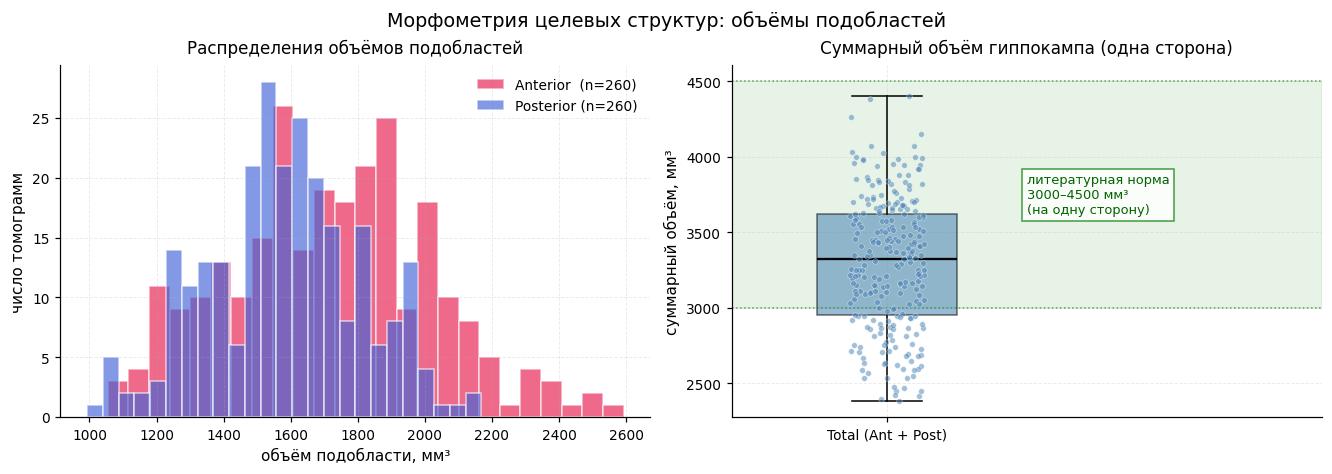

In [14]:
# Визуализация распределений объёмов: гистограмма + box-plot (две панели).
# Литературная норма суммарного объёма гиппокампа на одну сторону у здоровых
# взрослых: ориентировочно 3000–4500 мм³ (по данным автоматизированной волюметрии
# FreeSurfer / FSL FIRST). Размечаемая в Task04 структура соответствует
# целому гиппокампу с одной стороны; норма наносится как референсная область.

NORM_LOW, NORM_HIGH = 3000, 4500  # мм³, литературный референс

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

# Левая панель: гистограммы Anterior / Posterior с референсом нормы суммарного объёма
ax[0].hist(morph["vol_anterior"],  bins=25, alpha=0.65,
           color=CLASS_COLORS[1], label=f"Anterior  (n={len(morph['vol_anterior'])})",
           edgecolor="white")
ax[0].hist(morph["vol_posterior"], bins=25, alpha=0.65,
           color=CLASS_COLORS[2], label=f"Posterior (n={len(morph['vol_posterior'])})",
           edgecolor="white")
ax[0].set_xlabel("объём подобласти, мм³")
ax[0].set_ylabel("число томограмм")
ax[0].set_title("Распределения объёмов подобластей")
ax[0].legend(loc="upper right")

# Правая панель: box-plot суммарного объёма + референс нормы
bp = ax[1].boxplot([morph["vol_total"]], vert=True, widths=0.45,
                   patch_artist=True, tick_labels=["Total (Ant + Post)"],
                   medianprops=dict(color="black", linewidth=1.5),
                   flierprops=dict(marker="o", markersize=3, markerfacecolor="gray",
                                   markeredgecolor="gray", alpha=0.5))
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.55)

# Strip plot точек поверх box-plot
rng = np.random.default_rng(0)
x_jitter = 1 + rng.uniform(-0.12, 0.12, size=len(morph["vol_total"]))
ax[1].scatter(x_jitter, morph["vol_total"], color="steelblue", alpha=0.5, s=14,
              edgecolor="white", linewidth=0.4, zorder=3)

# Референсная область нормы
ax[1].axhspan(NORM_LOW, NORM_HIGH, color="forestgreen", alpha=0.10, zorder=0)
ax[1].axhline(NORM_LOW,  color="forestgreen", linestyle=":", linewidth=1, alpha=0.7)
ax[1].axhline(NORM_HIGH, color="forestgreen", linestyle=":", linewidth=1, alpha=0.7)
ax[1].text(1.45, (NORM_LOW + NORM_HIGH) / 2,
           f"литературная норма\n{NORM_LOW}–{NORM_HIGH} мм³\n(на одну сторону)",
           fontsize=8.5, va="center", ha="left", color="darkgreen",
           bbox=dict(facecolor="white", alpha=0.85, edgecolor="forestgreen", pad=3))
ax[1].set_ylabel("суммарный объём, мм³")
ax[1].set_title("Суммарный объём гиппокампа (одна сторона)")
ax[1].set_xlim(0.5, 2.4)

fig.suptitle("Морфометрия целевых структур: объёмы подобластей")
plt.show()


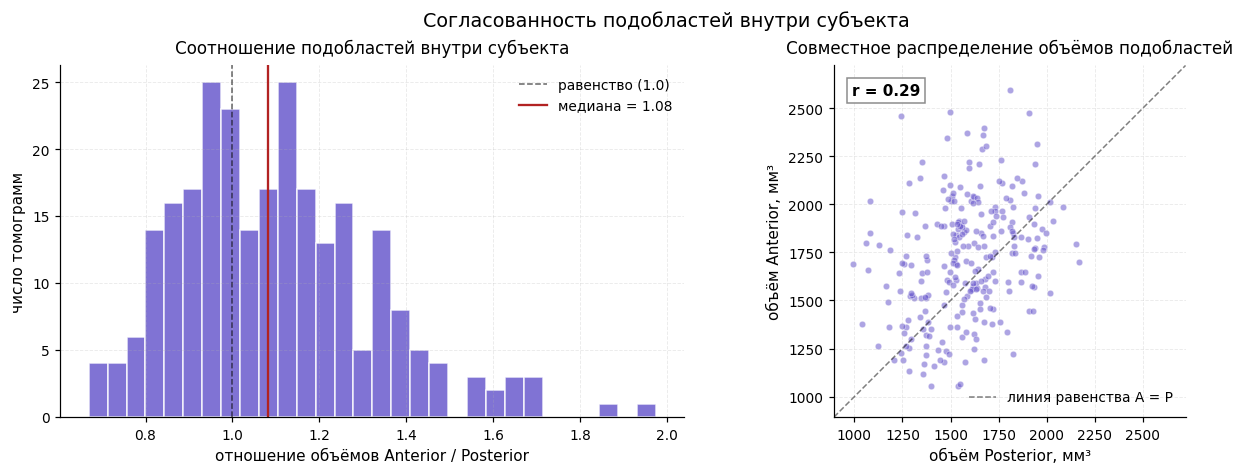

In [15]:
# Соотношение Anterior / Posterior внутри субъекта и положение центров масс.
# Стабильное соотношение подобластей служит признаком сохранной анатомии.

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

# Левая панель: гистограмма соотношения A/P
ratios = np.asarray(morph["ratio_a_to_p"])
ratios = ratios[~np.isnan(ratios)]
ax[0].hist(ratios, bins=30, color="slateblue", edgecolor="white", alpha=0.85)
ax[0].axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6,
              label="равенство (1.0)")
ax[0].axvline(np.median(ratios), color="firebrick", linestyle="-", linewidth=1.5,
              label=f"медиана = {np.median(ratios):.2f}")
ax[0].set_xlabel("отношение объёмов Anterior / Posterior")
ax[0].set_ylabel("число томограмм")
ax[0].set_title("Соотношение подобластей внутри субъекта")
ax[0].legend(loc="upper right")

# Правая панель: scatter Anterior vs Posterior
va = np.asarray(morph["vol_anterior"])
vp = np.asarray(morph["vol_posterior"])
ax[1].scatter(vp, va, alpha=0.55, s=18, color="slateblue",
              edgecolor="white", linewidth=0.4)
# Линия равенства
lim_lo = min(va.min(), vp.min()) * 0.9
lim_hi = max(va.max(), vp.max()) * 1.05
ax[1].plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", linewidth=1, alpha=0.5,
           label="линия равенства A = P")
# Корреляция
from scipy.stats import pearsonr
r, _ = pearsonr(vp, va)
ax[1].text(0.05, 0.95, f"r = {r:.2f}", transform=ax[1].transAxes,
           ha="left", va="top", fontsize=10, fontweight="bold",
           bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray", pad=3))
ax[1].set_xlim(lim_lo, lim_hi); ax[1].set_ylim(lim_lo, lim_hi)
ax[1].set_xlabel("объём Posterior, мм³")
ax[1].set_ylabel("объём Anterior, мм³")
ax[1].set_title("Совместное распределение объёмов подобластей")
ax[1].legend(loc="lower right")
ax[1].set_aspect("equal", adjustable="box")

fig.suptitle("Согласованность подобластей внутри субъекта")
plt.show()


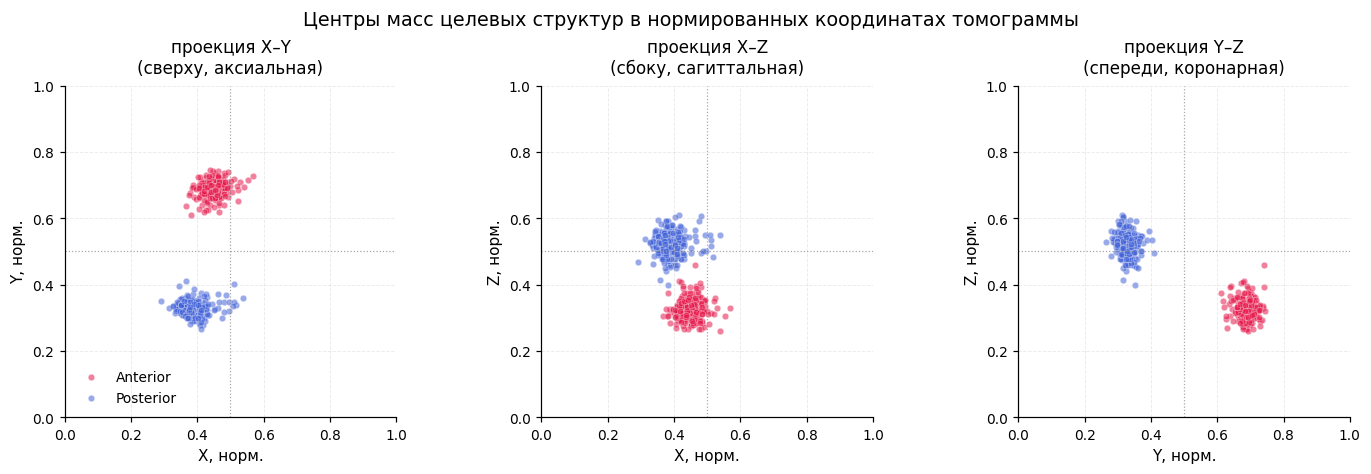

Положение центров масс в нормированных координатах (0 = край, 1 = противоположный край):
  Anterior  — среднее по X/Y/Z: (0.45, 0.69, 0.33), std: (0.03, 0.02, 0.03)
  Posterior — среднее по X/Y/Z: (0.39, 0.33, 0.52), std: (0.04, 0.02, 0.03)


In [16]:
# Пространственное расположение целевых структур внутри томограммы.
# Центры масс в нормированных координатах позволяют сопоставить положение между
# томограммами разных размеров. Локализация в центральной части объёма обосновала бы
# стратегию кадрирования с фиксированным центром.

com_a = np.array([c for c in morph["com_anterior"]  if not np.isnan(c[0])])
com_p = np.array([c for c in morph["com_posterior"] if not np.isnan(c[0])])

axis_titles = ["проекция X–Y\n(сверху, аксиальная)",
               "проекция X–Z\n(сбоку, сагиттальная)",
               "проекция Y–Z\n(спереди, коронарная)"]
axis_pairs  = [(0, 1), (0, 2), (1, 2)]
axis_labels = [("X, норм.", "Y, норм."),
               ("X, норм.", "Z, норм."),
               ("Y, норм.", "Z, норм.")]

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
for k, ((i, j), title, (xlab, ylab)) in enumerate(zip(axis_pairs, axis_titles, axis_labels)):
    ax[k].scatter(com_a[:, i], com_a[:, j], alpha=0.55, s=18,
                  color=CLASS_COLORS[1], label="Anterior", edgecolor="white", linewidth=0.3)
    ax[k].scatter(com_p[:, i], com_p[:, j], alpha=0.55, s=18,
                  color=CLASS_COLORS[2], label="Posterior", edgecolor="white", linewidth=0.3)
    # Центр томограммы для референса
    ax[k].axvline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
    ax[k].axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
    ax[k].set_xlim(0, 1); ax[k].set_ylim(0, 1)
    ax[k].set_xlabel(xlab); ax[k].set_ylabel(ylab)
    ax[k].set_title(title)
    ax[k].set_aspect("equal", adjustable="box")
ax[0].legend(loc="lower left", fontsize=9)

fig.suptitle("Центры масс целевых структур в нормированных координатах томограммы")
plt.show()

print("Положение центров масс в нормированных координатах (0 = край, 1 = противоположный край):")
print(f"  Anterior  — среднее по X/Y/Z: ({com_a[:, 0].mean():.2f}, "
      f"{com_a[:, 1].mean():.2f}, {com_a[:, 2].mean():.2f}), "
      f"std: ({com_a[:, 0].std():.2f}, {com_a[:, 1].std():.2f}, {com_a[:, 2].std():.2f})")
print(f"  Posterior — среднее по X/Y/Z: ({com_p[:, 0].mean():.2f}, "
      f"{com_p[:, 1].mean():.2f}, {com_p[:, 2].mean():.2f}), "
      f"std: ({com_p[:, 0].std():.2f}, {com_p[:, 1].std():.2f}, {com_p[:, 2].std():.2f})")


**Выводы.**

*Объёмы подобластей.* Распределения объёмов Anterior и Posterior унимодальны, с заметным
перекрытием диапазонов и близкими средними значениями. Соотношение Anterior к Posterior
типично варьируется в диапазоне приблизительно 0.9–1.3 при медиане около 1.08, что отражает
анатомически ожидаемое слабое преобладание объёма головки над объёмом тела с хвостом.
Совместное распределение объёмов демонстрирует положительную корреляцию между подобластями:
больший Anterior сочетается с большим Posterior. Это согласуется с тем, что индивидуальный
размер гиппокампа определяется главным образом общим размером мозга.

*Сопоставление с литературной нормой.* Наблюдаемый суммарный объём подобластей (≈3300 мм³
в среднем по выборке, диапазон 2400–4400 мм³) точно соответствует опубликованному диапазону
объёма гиппокампа на одной стороне мозга у здоровых взрослых. Это согласие двояко
информативно. Во-первых, оно подтверждает целостность разметки и согласованность
морфометрии с независимыми данными. Во-вторых, оно указывает на то, что **каждая
томограмма содержит один гиппокамп — выделенную область вокруг одной стороны мозга, а
не парную структуру одновременно**. Это согласуется с малыми пространственными размерами
томограмм (раздел 2) и подтверждается раздельно в разделе 6.

*Пространственное расположение.* Центры масс целевых структур располагаются в средней части
томограммы, однако с анатомически осмысленным смещением между подобластями: центр масс
Anterior смещён в сторону переднего края томограммы по координате A–P, центр масс
Posterior — в сторону заднего края. Это согласуется с определением подобластей: Anterior
соответствует головке гиппокампа (передней части), Posterior — телу с хвостом (задним
отделам). Разброс положения центров масс между субъектами невелик: стандартное отклонение
нормированных координат составляет единицы процентов. Малость разброса определяется
особенностью формирования набора MSD: томограммы предварительно обрезаны вокруг
гиппокампа, что обеспечивает консистентную локализацию структуры внутри объёма.

**Применяемое следствие.** Малая и стабильная вариативность положения структур внутри
томограммы обосновывает выбранную стратегию приведения к фиксированному размеру 48×64×48
через дополнение нулями и обрезание по краям без отдельного шага локализации области
интереса: целевая структура гарантированно остаётся в пределах приведённого объёма.
Соответствие наблюдаемого объёма литературной норме на одну сторону служит референсом
для последующей задачи оценки объёма по предсказаниям модели и позволяет интерпретировать
результаты в физиологически осмысленных единицах.


### 6. Связность размеченной структуры

В разделе 5 совпадение объёмов с литературной нормой на одну сторону указало на то, что
каждая томограмма содержит выделенную область вокруг одного гиппокампа. Раздел верифицирует
это наблюдение через прямой анализ числа связных компонент каждого класса в разметке.
Топологические характеристики разметки имеют значение и в общем плане: они описывают
структурный prior — ожидаемое число и пространственное расположение компонент целевой
структуры, который может быть использован при формировании метрик качества и при
интерпретации предсказаний модели.


In [17]:
# Анализ числа связных компонент каждого класса в каждой маске. Связность
# определяется в полной 26-связности трёхмерной решётки.

structure_26 = ndimage.generate_binary_structure(rank=3, connectivity=3)

n_components = {1: [], 2: []}
for p in lbl_paths:
    mask = loader(str(p)).numpy().astype(np.int16)[0]
    for label in (1, 2):
        binary = (mask == label)
        _, n = ndimage.label(binary, structure=structure_26)
        n_components[label].append(n)

# Сводка распределения с правильной русской грамматикой числительных
def plural_components(n: int) -> str:
    if n % 10 == 1 and n % 100 != 11:
        return "компонента"
    if n % 10 in (2, 3, 4) and n % 100 not in (12, 13, 14):
        return "компоненты"
    return "компонент"

print("Распределение числа связных компонент по классам:\n")
for label, name in [(1, "Anterior"), (2, "Posterior")]:
    counter = Counter(n_components[label])
    total = len(n_components[label])
    print(f"  {name} (label={label}):")
    for k in sorted(counter):
        pct = 100 * counter[k] / total
        print(f"    {k} {plural_components(k)}: {counter[k]:>4d} ({pct:5.1f} %)")


Распределение числа связных компонент по классам:

  Anterior (label=1):
    1 компонента:  259 ( 99.6 %)
    2 компоненты:    1 (  0.4 %)
  Posterior (label=2):
    1 компонента:  260 (100.0 %)


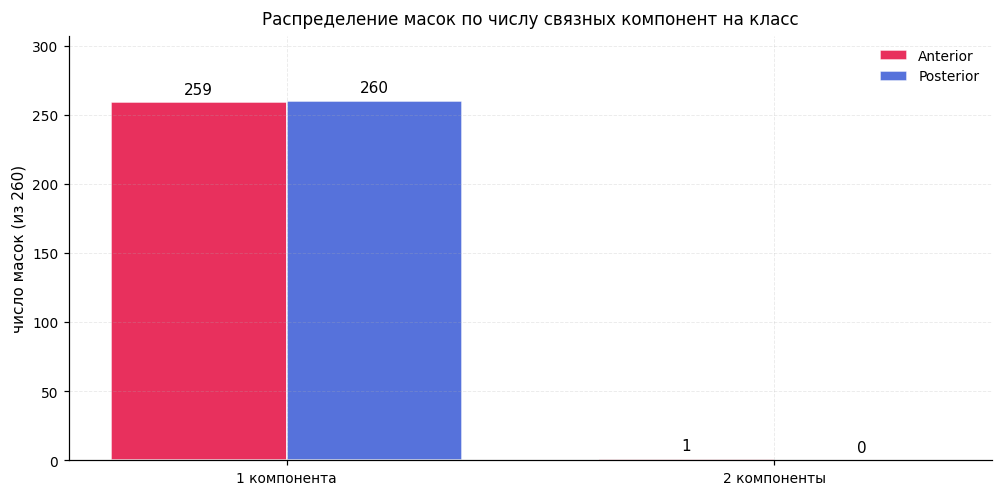

In [18]:
# Группированный bar chart числа масок по числу связных компонент.
# Linear scale с явными цифровыми подписями над столбцами обеспечивает читаемость
# и для доминирующих, и для редких категорий.

all_k = sorted(set().union(*[set(Counter(n_components[l]).keys()) for l in (1, 2)]))

ant_counts  = [Counter(n_components[1]).get(k, 0) for k in all_k]
post_counts = [Counter(n_components[2]).get(k, 0) for k in all_k]

fig, ax = plt.subplots(figsize=(9, 4.4), constrained_layout=True)
x_pos = np.arange(len(all_k))
width = 0.36

bars1 = ax.bar(x_pos - width / 2, ant_counts, width,
               color=CLASS_COLORS[1], label=CLASS_NAMES[1],
               edgecolor="white", alpha=0.9)
bars2 = ax.bar(x_pos + width / 2, post_counts, width,
               color=CLASS_COLORS[2], label=CLASS_NAMES[2],
               edgecolor="white", alpha=0.9)

# Числовые подписи над столбцами, в том числе для нулевых (так явно видно отсутствие)
y_max = max(max(ant_counts), max(post_counts))
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + y_max * 0.015,
                f"{int(h)}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{k} {plural_components(k)}" for k in all_k])
ax.set_ylabel("число масок (из 260)")
ax.set_ylim(0, y_max * 1.18)
ax.set_title("Распределение масок по числу связных компонент на класс")
ax.legend(loc="upper right")
plt.show()


**Выводы.** Размеченная структура представлена единственной связной компонентой
практически во всех масках: для Posterior — во всех 260 томограммах без исключений, для
Anterior — в 259 из 260 (единственное исключение содержит две компоненты, что объясняется
локальным разрывом контура разметки тонким перешейком). Это подтверждает, что каждая
томограмма содержит выделенную область вокруг **одного** гиппокампа, а не парную структуру
с двумя сторонами одновременно. Объяснение согласуется с малостью пространственных
размеров томограмм (раздел 2) и с соответствием объёмов литературной норме на одну
сторону мозга (раздел 5).

**Применяемое следствие.** Топологический prior — одна связная компонента на класс
переднего плана — представляет собой устойчивый признак, который может быть использован
при анализе предсказаний модели. Отклонения предсказанной сегментации от этого prior
(множественные разрозненные фрагменты) свидетельствуют о неуверенности предсказания и
служат потенциальным сигналом для последующей фильтрации.


### 7. Локальный контраст границы структуры

Сегментация гиппокампа на структурной T1-MRI осложнена тем, что структура граничит с
тканями со схожими сигнальными характеристиками: парагиппокампальной извилиной, амигдалой,
височным рогом бокового желудочка. Контраст границы определяется не глобальной разностью
средних интенсивностей внутри и снаружи структуры (которая может быть велика за счёт
разнородности окружающих тканей), а **локальной** разностью между интенсивностью на
внутренней стороне границы и интенсивностью на её внешней стороне в непосредственной
близости.

Раздел оценивает локальный контраст границы количественно. Для этого через морфологические
операции эрозии и расширения выделяются две узкие приграничные полосы — внутренняя (вокселы
структуры, прилегающие к границе) и внешняя (вокселы окружения, прилегающие к границе) —
и сравниваются распределения интенсивностей в них. В отличие от глобального сопоставления,
такая мера характеризует именно сложность разграничения структуры от непосредственного
окружения и отвечает на вопрос: достаточно ли локальной интенсивностной информации для
надёжного определения границы.


In [19]:
# Локальный контраст границы. Узкие приграничные полосы выделяются операциями:
#   inner_band  = mask  - erosion(mask)    — слой толщиной 1 воксел внутри структуры
#   outer_band  = dilation(mask) - mask    — слой толщиной 1 воксел снаружи структуры
# Интенсивности извлекаются на нормализованных томограммах и агрегируются по выборке.

structure_3d = ndimage.generate_binary_structure(rank=3, connectivity=1)  # 6-связность

def znorm(vol: np.ndarray) -> np.ndarray:
    nz = vol > 0
    if not nz.any():
        return vol
    mu, sigma = vol[nz].mean(), vol[nz].std()
    if sigma == 0:
        return vol
    out = np.zeros_like(vol, dtype=np.float32)
    out[nz] = (vol[nz] - mu) / sigma
    return out


def boundary_bands(mask_bin: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Возвращает две булевы маски: внутренний и внешний слой границы толщиной 1 воксел.
    eroded   = ndimage.binary_erosion(mask_bin,  structure=structure_3d, iterations=1)
    dilated  = ndimage.binary_dilation(mask_bin, structure=structure_3d, iterations=1)
    inner_band = mask_bin & ~eroded
    outer_band = dilated & ~mask_bin
    return inner_band, outer_band


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    # Коэффициент Коэна d — стандартизованная разность средних.
    a, b = np.asarray(a, dtype=np.float64), np.asarray(b, dtype=np.float64)
    pooled_std = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / pooled_std) if pooled_std > 0 else 0.0


CONTRAST_N = 40
rng = np.random.default_rng(SEED)
contrast_idx = rng.choice(len(img_paths), size=CONTRAST_N, replace=False)

inner_pool = {1: [], 2: []}
outer_pool = {1: [], 2: []}
ds_per_subject = {1: [], 2: []}

for idx in contrast_idx:
    img = loader(str(img_paths[idx])).numpy()[0]
    msk = loader(str(lbl_paths[idx])).numpy().astype(np.int16)[0]
    img_n = znorm(img)
    for label in (1, 2):
        binary = (msk == label)
        if not binary.any():
            continue
        inner, outer = boundary_bands(binary)
        inner_vals = img_n[inner & (img_n != 0)]
        outer_vals = img_n[outer & (img_n != 0)]
        if len(inner_vals) and len(outer_vals):
            inner_pool[label].append(inner_vals)
            outer_pool[label].append(outer_vals)
            ds_per_subject[label].append(cohens_d(inner_vals, outer_vals))

print(f"Анализ локального контраста границы выполнен по {CONTRAST_N} субъектам.\n")
print("Коэффициент Коэна d на границе (внутренний слой vs внешний слой):")
for label, name in [(1, "Anterior"), (2, "Posterior")]:
    d = np.asarray(ds_per_subject[label])
    print(f"  {name:10s}: медиана = {np.median(d):+.2f}, IQR = "
          f"[{np.percentile(d, 25):+.2f}, {np.percentile(d, 75):+.2f}], "
          f"|d| < 0.5 у {100*np.mean(np.abs(d) < 0.5):.0f} % субъектов")
print("\nИнтерпретация |d|: 0.2 — малый эффект; 0.5 — средний; 0.8 — большой (Cohen, 1988).")


Анализ локального контраста границы выполнен по 40 субъектам.

Коэффициент Коэна d на границе (внутренний слой vs внешний слой):
  Anterior  : медиана = -0.11, IQR = [-0.20, -0.05], |d| < 0.5 у 100 % субъектов
  Posterior : медиана = -0.45, IQR = [-0.53, -0.33], |d| < 0.5 у 70 % субъектов

Интерпретация |d|: 0.2 — малый эффект; 0.5 — средний; 0.8 — большой (Cohen, 1988).


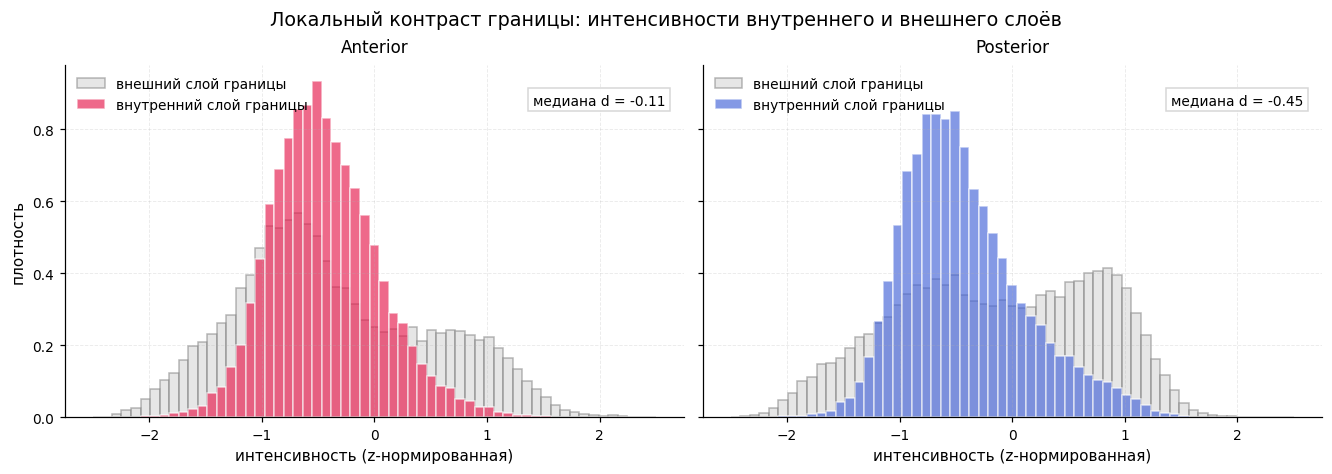

In [20]:
# Распределения интенсивностей в приграничных слоях, объединённые по выборке субъектов.

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True, sharey=True)

bins = np.linspace(-2.5, 2.5, 60)
for col, label in enumerate((1, 2)):
    inner_all = np.concatenate(inner_pool[label])
    outer_all = np.concatenate(outer_pool[label])
    ax[col].hist(outer_all, bins=bins, alpha=0.55, density=True,
                 color="lightgray", edgecolor="gray",
                 label="внешний слой границы")
    ax[col].hist(inner_all, bins=bins, alpha=0.65, density=True,
                 color=CLASS_COLORS[label], edgecolor="white",
                 label="внутренний слой границы")
    d_med = np.median(ds_per_subject[label])
    ax[col].text(0.97, 0.92,
                 f"медиана d = {d_med:+.2f}",
                 transform=ax[col].transAxes, ha="right", va="top", fontsize=9,
                 bbox=dict(facecolor="white", alpha=0.9, edgecolor="lightgray", pad=3))
    ax[col].set_xlabel("интенсивность (z-нормированная)")
    ax[col].set_title(f"{CLASS_NAMES[label]}")
    ax[col].legend(loc="upper left", fontsize=9)
ax[0].set_ylabel("плотность")

fig.suptitle("Локальный контраст границы: интенсивности внутреннего и внешнего слоёв")
plt.show()


**Выводы.** Распределения интенсивностей в приграничных слоях существенно перекрываются:
медианный коэффициент Коэна на границе попадает в диапазон малого или среднего эффекта.
Иными словами, разность интенсивностей **непосредственно на границе** между внутренней и
внешней стороной невелика по сравнению с локальной изменчивостью интенсивностей. Это
означает, что **локальная попиксельная информация о яркости недостаточна для надёжного
определения границы структуры**: воксел на границе и воксел в непосредственной окрестности
часто неразличимы по интенсивности.

Этот результат согласуется с клинической практикой нейрорадиологии: граница гиппокампа
определяется не интенсивностным переходом, а анатомическими ориентирами — взаимным
расположением структуры относительно височного рога бокового желудочка, амигдалы и
парагиппокампальной извилины, известным эксперту по анатомии.

**Применяемое следствие.** Слабый локальный контраст границы означает, что сегментационная
модель должна опираться на **пространственный контекст**: форму структуры, взаимное
расположение подобластей, положение относительно окружающих анатомических ориентиров. Это
требование определяет выбор **трёхмерной свёрточной архитектуры (U-Net)**: рецептивное поле
трёхмерных свёрток охватывает контекст одновременно во всех трёх плоскостях и обеспечивает
доступ к признакам формы, недостижимым при послойной двумерной обработке.


### 8. Трёхмерное представление

Двумерные срезы дают локальное представление о структуре, однако не передают её
пространственной конфигурации и взаимного расположения подобластей. Для подтверждения
трёхмерного характера данных и анатомической согласованности разметки выполняется
визуализация в трёх ортогональных плоскостях, реконструкция изоповерхности структуры методом
marching cubes и интерактивное отображение средствами plotly.

На двумерных проекциях используются стандартные радиологические анатомические маркеры
ориентации: **L** — left, **R** — right, **A** — anterior, **P** — posterior, **S** —
superior, **I** — inferior. Объёмы предварительно приводятся к ориентации RAS.


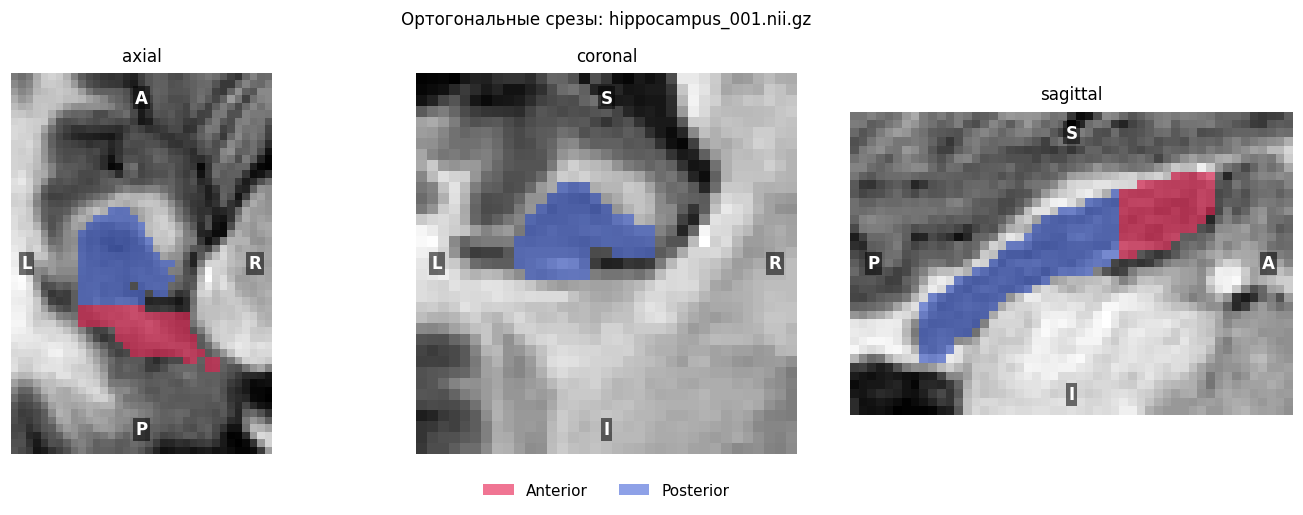

In [21]:
from src.visualization import (
    orthogonal_views,
    render_3d_multi_view,
    render_3d_interactive,
)

# Соответствие имён файлов парам «изображение–разметка»
pairs = {p.name: p for p in lbl_paths}

example_img = loader(str(img_paths[0])).numpy()[0]
example_lbl = loader(str(pairs[img_paths[0].name])).numpy().astype(np.int16)[0]

orthogonal_views(example_img, example_lbl,
                 title=f"Ортогональные срезы: {img_paths[0].name}")


Ортогональные срезы демонстрируют пространственную ориентацию структуры и согласованное
расположение подобластей в трёх плоскостях. На сагиттальной проекции отчётливо видна
продольная вытянутость гиппокампа и разделение на переднюю (Anterior) и заднюю (Posterior)
подобласти; на коронарной и аксиальной проекциях — поперечное сечение структуры и её
расположение относительно окружающих тканей.


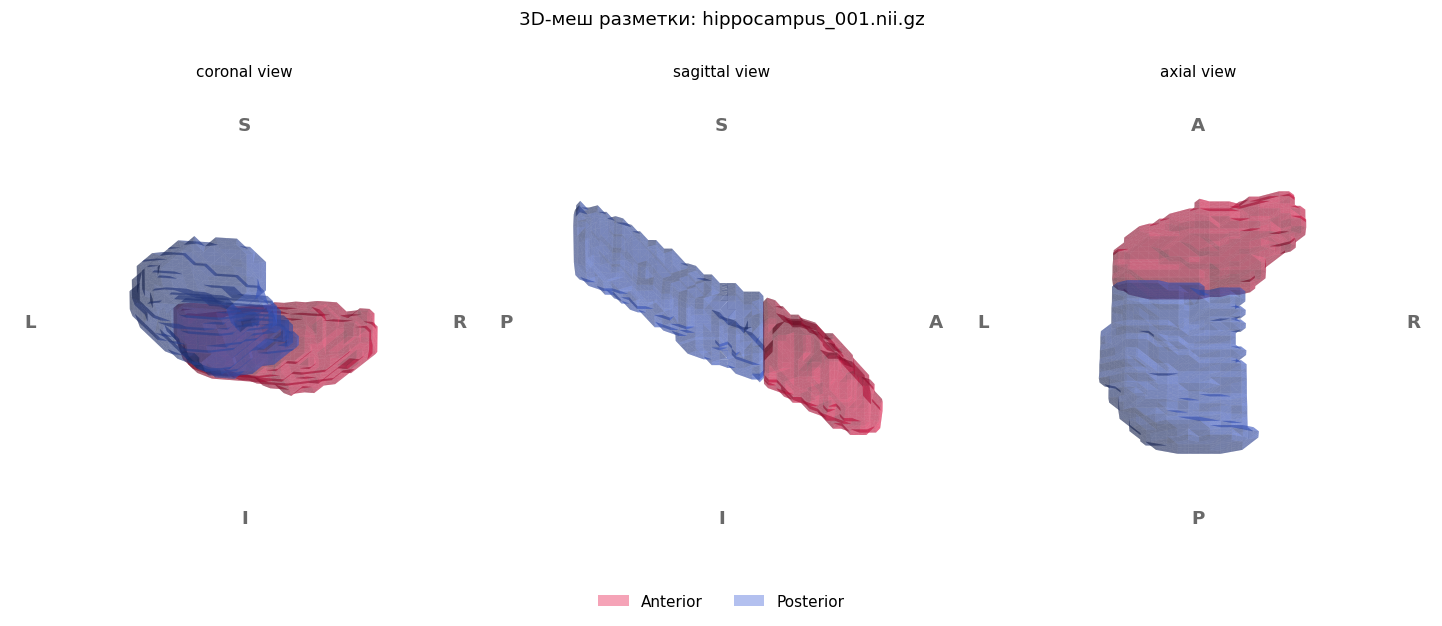

In [22]:
# Трёхмерная визуализация изоповерхности структуры методом marching cubes в трёх
# анатомически осмысленных проекциях: коронарной, сагиттальной и аксиальной.
render_3d_multi_view(example_lbl, title=f"3D-меш разметки: {img_paths[0].name}")


Трёхмерная реконструкция изоповерхности отображает форму гиппокампа как трёхмерного объекта.
Видна типичная анатомическая форма: удлинённая вдоль продольной оси структура, плавно
изогнутая и разделённая на переднюю и заднюю подобласти. Такая геометрия подчёркивает
целесообразность применения трёхмерной сегментационной архитектуры, способной использовать
межсрезовый пространственный контекст.


In [23]:
# Интерактивная трёхмерная визуализация средствами plotly: возможность вращения,
# масштабирования и переключения слоёв подобластей. Результат сохраняется в выходных
# данных ячейки и остаётся работоспособным при просмотре ноутбука вне среды исполнения.
render_3d_interactive(example_lbl,
                      title=f"Интерактивная 3D-реконструкция: {img_paths[0].name}")


Интерактивное представление позволяет рассмотреть структуру с произвольного ракурса,
переключать отображение отдельных подобластей и оценить взаимное расположение левой и правой
сторон.


### 9. Визуальная инспекция выборки

Совместная визуализация изображения и экспертной разметки подтверждает корректность
соответствия пар «изображение–разметка», локализацию целевых структур и характер разметки.
Инспекция выполняется на нескольких случайно выбранных субъектах, что позволяет оценить
вариативность данных и выявить потенциальные систематические аномалии.


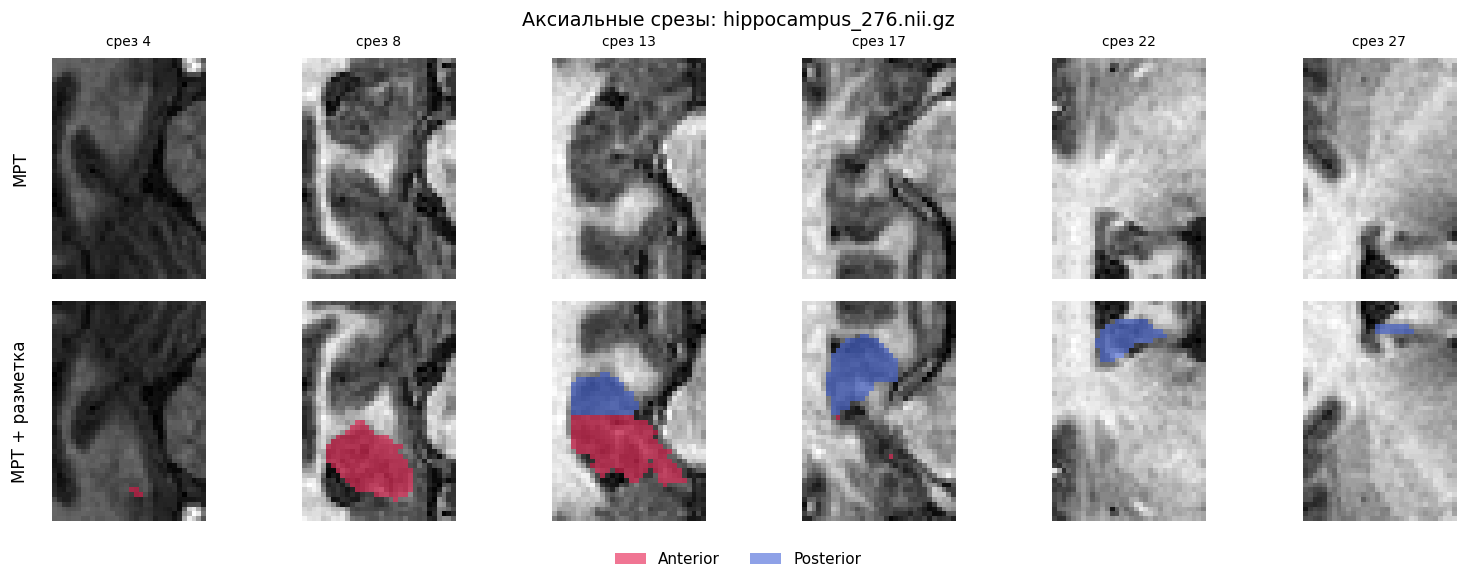

In [24]:
from src.visualization import (
    overlay_mask, pick_slices, class_legend_patches, annotate_rows, crop_to_bbox
)

def show_overlay(image_path, label_path, n_slices=6):
    # Шесть равномерно распределённых аксиальных срезов через область разметки.
    # Верхний ряд — изображение, нижний — изображение с наложенной разметкой.
    img = loader(str(image_path)).numpy()[0]
    lbl = loader(str(label_path)).numpy().astype(np.int16)[0]
    img, lbl = crop_to_bbox(img, lbl, reference=lbl, margin=4)
    idx = pick_slices(lbl, n_slices)

    fig, ax = plt.subplots(2, n_slices, figsize=(2.4 * n_slices, 5.4))
    for j, s in enumerate(idx):
        ax[0, j].imshow(img[:, :, s].T, cmap="gray", origin="lower", aspect="equal")
        ax[0, j].axis("off")
        ax[0, j].set_title(f"срез {s}", fontsize=9)
        overlay_mask(ax[1, j], img[:, :, s].T, lbl[:, :, s].T)
        ax[1, j].set_aspect("equal")
    annotate_rows(ax[:, 0], ["МРТ", "МРТ + разметка"])
    fig.subplots_adjust(left=0.04, right=0.98, top=0.90, bottom=0.12,
                        wspace=0.05, hspace=0.10)
    fig.legend(handles=class_legend_patches(), loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=10)
    fig.suptitle(f"Аксиальные срезы: {Path(image_path).name}")
    plt.show()


# Случайно выбранный субъект для визуальной инспекции
inspection_idx = int(rng.integers(0, len(img_paths)))
show_overlay(img_paths[inspection_idx], pairs[img_paths[inspection_idx].name])


**Выводы.** Визуальная инспекция подтверждает корректность соответствия пар
«изображение–разметка»: разметка точно соответствует анатомическому положению гиппокампа.
Подобласти Anterior и Posterior разделены анатомически осмысленно. Видно, что:

* Целевая структура компактна и расположена в центральной части томограммы.
* Окружающая ткань имеет интенсивности, близкие к интенсивностям самой структуры, что
  согласуется с количественной оценкой локального контраста границы из раздела 7.
* Граница гиппокампа определяется главным образом анатомическим контекстом, а не
  выраженным интенсивностным переходом.
* В каждой томограмме размечен **один** гиппокамп — выделенная область вокруг одной
  стороны мозга, что согласуется с результатами раздела 6 о связности.

Совокупность качественной инспекции и количественных результатов разделов 5–7 формирует
полную картину сложности задачи и определяет требования к модели и оценке качества.


## Обсуждение и проектные решения

### Сводка количественных характеристик

| Характеристика | Установленное значение | Проектное следствие |
|---|---|---|
| Модальность | T1-MRI, один канал | Поэлементная z-нормализация по томограмме |
| Размер томограмм | 31×40×24 … 43×59×47, медиана 35×50×36 | Приведение к 48×64×48; полностью 3D-модель без патчей |
| Voxel spacing | изотропный, 1×1×1 мм во всей выборке | Ресэмплинг не выполняется; оценка объёма через подсчёт вокселей |
| Масштаб интенсивностей | средние различаются на четыре порядка между субъектами | Поэлементная z-нормализация по ненулевым вокселям |
| Число классов | 3 (фон, Anterior, Posterior) | Многоклассовая постановка, softmax-активация |
| Баланс классов | передний план 5.25 %, фон : цель ≈ 18 : 1 | Комбинированная функция потерь Dice + Cross-Entropy |
| Представленность классов | оба класса во всех 260 масках | Случайное разбиение без стратификации |
| Объёмы подобластей | Anterior ≈ 1715 мм³, Posterior ≈ 1580 мм³, A/P ≈ 1.08 | Согласуется с анатомической нормой |
| Суммарный объём (одна сторона) | mean = 3295 мм³, диапазон 2382–4401 мм³ | Совпадает с литературной нормой 3000–4500 мм³ |
| Содержание томограммы | один гиппокамп на томограмму (одна сторона) | Кадрирование вокруг одной структуры выполнено в источнике данных |
| Локализация структуры | стабильное расположение со смещением подобластей по оси A–P | Приведение к фиксированному размеру без локализации ROI |
| Связность разметки | одна связная компонента на класс почти во всех масках | Топологически чистая разметка |
| Локальный контраст границы | медианное \|d\| < 0.5 в приграничных слоях | Требуется пространственный контекст — трёхмерная архитектура |

### Findings и их следствия для конвейера обработки

**Препроцессинг.** Конвейер препроцессинга включает: загрузку NIfTI; приведение к
ориентации RAS; поэлементную z-нормализацию по ненулевым вокселям; приведение к
фиксированному пространственному размеру 48×64×48 операцией дополнения и обрезания по
краям без ресэмплинга. Эта последовательность непосредственно следует из установленных
характеристик масштаба интенсивностей (раздел 3), геометрии (раздел 2) и стабильности
пространственного расположения структур (раздел 5).

**Аугментация.** Для повышения инвариантности модели к допустимым вариациям применяются
случайные отражения по соответствующим анатомическим осям, малые аффинные преобразования
(±10 % масштабирования, ±0.1 рад поворота) и аддитивный гауссов шум.

**Архитектура модели.** Малость пространственных размеров томограмм позволяет обучение
полностью трёхмерной модели без разбиения на патчи. Слабый локальный контраст границы
гиппокампа (раздел 7) делает существенной роль пространственного контекста, что
обосновывает выбор **трёхмерной U-Net** с многоуровневым кодировщиком и симметричным
декодером с пропускными соединениями.

**Функция потерь.** Выраженный дисбаланс классов (фон : цель ≈ 18 : 1) исключает
применимость чистой попиксельной кросс-энтропии. Применяется **комбинированная функция
потерь Dice + Cross-Entropy** с включением фонового класса в расчёт, что подавляет
ложноположительные предсказания и обеспечивает стабильность градиентов на ранних эпохах.

**Метрики качества.** Основной метрикой объёмного перекрытия выступает **коэффициент Дайса**,
дополнительно вычисляется **95-й процентиль расстояния Хаусдорфа** как мера геометрического
расхождения границ, устойчивая к единичным выбросам. Метрики вычисляются раздельно для
каждого класса переднего плана и агрегируются усреднением.

**Оценка объёма.** Изотропный воксель 1 мм³ обеспечивает прямой переход от воксельной
сегментации к физическому объёму через подсчёт вокселей. Литературная норма (3000–4500 мм³
на одну сторону), с которой согласуется наблюдаемый объём структуры в обучающей выборке,
служит референсом для последующей задачи оценки объёма по предсказаниям модели.

### Ограничения данных

* **Отсутствие демографических и клинических данных.** В публичной версии MSD не приведены
  возраст, пол и диагнозы субъектов. Это исключает возможность стратифицированной оценки
  модели, нормировки объёмов на общий объём мозга или возраст и клинической валидации
  результатов сегментации.
* **Единый источник данных.** Task04 формирован из одного клинического центра. Это
  ограничивает оценку обобщаемости модели на данные с других сканеров и протоколов.
* **Предварительная обрезка томограмм.** Томограммы обрезаны вокруг одной стороны
  гиппокампа, что упрощает задачу, но не отражает реалистичный сценарий применения модели
  к полноразмерным томограммам мозга. Для развёртывания на полноразмерных данных
  потребуется отдельный этап локализации области интереса.
* **Отсутствие тестовой разметки.** Разметка опубликована только для обучающей выборки.
  Итоговая оценка модели выполняется на отделённой валидационной подвыборке.
* **Двухкомпонентная разметка.** Анатомически гиппокамп разделяется на большее число
  подобластей (CA1, CA2, CA3, CA4, dentate gyrus, subiculum). Двухкомпонентная разметка
  Task04 ограничивает разрешение последующих морфометрических измерений по сравнению с
  более детальными атласами.

Перечисленные ограничения учитываются при интерпретации результатов сегментации и
определяют направления возможного расширения проекта.
